# Degradation Analysis

Notebook for the current `training_runs` layout.

Configuration in the first code cell:
- `DATASET_NAME`
- `LABEL_NAME`
- `TRAIN_MISSING_LOCATION`

Expected results path:
- `results/<DATASET_NAME>_<LABEL_NAME>/training_runs`
- the notebook raises an error if that directory does not exist

What the notebook does:
- automatically detects all model folders available under `training_runs`
- reads `outer_test_metrics.csv` for every available seed/run
- aggregates AUC first across outer folds within each seed, then across seeds
- computes `mean AUC`, `95% CI`, `degradation coefficient`, and `95% CI` for degradation

Generated figures:
- `AUC ± 95% CI` line plots for:
  - `Missing at Train`
  - `Missing at Test`
  - `Same Missingness at Both`
- `Degradation Coefficient ± 95% CI` line plots for the same three scenarios
- `AUC ± 95% CI` heatmaps across `train missing prop x test missing prop`
- `Degradation Coefficient ± 95% CI` heatmaps across `train missing prop x test missing prop`

Saved outputs:
- `analysis/figures/auc/`
- `analysis/figures/DC/`
- filenames include the number of detected models, for example `_5models`



In [261]:
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'analysis' else cwd

DATASET_NAME = 'MIMM'
LABEL_NAME = 'OS_9_label'
TRAIN_MISSING_LOCATION = 'GLOBAL'

BASE_LINE_FIGSIZE = (15.8, 10)
LINE_LEGEND_EXTRA_WIDTH_PER_MODEL = 0.55
BASE_HEATMAP_PANEL_WIDTH = 16.0 / 3.0
BASE_HEATMAP_PANEL_HEIGHT = 16.0 / 3.0
DEFAULT_LINE_FIGSIZE = BASE_LINE_FIGSIZE
DEFAULT_HEATMAP_FIGSIZE = (16.0, 10.0)

RESULTS_TAG = f'{DATASET_NAME}_{LABEL_NAME}' if str(LABEL_NAME).strip() else DATASET_NAME
RESULTS_ROOT = PROJECT_ROOT / 'results' / RESULTS_TAG / 'training_runs'
if not RESULTS_ROOT.exists():
    raise FileNotFoundError(
        f'Results root does not exist for dataset={DATASET_NAME!r}, label={LABEL_NAME!r}: {RESULTS_ROOT}'
    )
if not RESULTS_ROOT.is_dir():
    raise NotADirectoryError(f'Expected a directory at: {RESULTS_ROOT}')

ENDPOINT_NAME = LABEL_NAME if str(LABEL_NAME).strip() else RESULTS_ROOT.parent.name.replace(f'{DATASET_NAME}_', '', 1)

RESULTS_ROOT


PosixPath('/Users/marcalbesa/Desktop/TFM/git_exp/methods/results/MIMM_OS_9_label/training_runs')

In [262]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DISPLAY_NAME_MAP = {
    'ZERO_MLP': 'ZI_MLP',
    'KNN_MLP': 'KNN_MLP',
    'VAE_MLP': 'VAE_MLP',
    'PAM': 'pAM',
    'DIPAM': 'MLPDiPAM',
    'DI_PAM': 'MLPDiPAM',
    'MLPDIPAM': 'MLPDiPAM',
    'MLP_DIPAM': 'MLPDiPAM',
    'PAMDIPAM': 'PAMDiPAM',
    'PAM_DIPAM': 'PAMDiPAM',
    'HEALNET': 'HealNet',
    'SMILE': 'SMILe',
}

def _normalize_model_label(name: str) -> str:
    raw = str(name).strip()
    if '_retrain' in raw:
        raw = raw.split('_retrain', 1)[0]
    compact = raw.replace('-', '_').upper()
    return DISPLAY_NAME_MAP.get(compact, raw)

def list_model_sources(results_root: Path, dataset_name: str, train_missing_location: str, model_names=None):
    sources = []
    requested = None if model_names is None else set(model_names)

    for run_dir in sorted(p for p in results_root.iterdir() if p.is_dir() and not p.name.startswith('.')):
        model_label = _normalize_model_label(run_dir.name)
        if requested is not None and model_label not in requested:
            continue

        candidate_dirs = [p for p in run_dir.iterdir() if p.is_dir() and not p.name.startswith('.')]
        train_missing_dir = None
        for candidate_dir in candidate_dirs:
            probe = candidate_dir / dataset_name.upper() / 'TRAIN_MISSING' / train_missing_location.upper()
            if probe.exists():
                train_missing_dir = probe
                break
        if train_missing_dir is None:
            continue

        sources.append({
            'model_name': model_label,
            'run_dir': run_dir,
            'train_missing_dir': train_missing_dir,
        })
    return sources

def resolve_requested_model_names(results_root: Path, dataset_name: str, train_missing_location: str):
    return sorted({
        source['model_name']
        for source in list_model_sources(results_root, dataset_name, train_missing_location, model_names=None)
    })

def list_train_missing_props(train_missing_dir: Path):
    props = []
    for p in train_missing_dir.iterdir():
        if not p.is_dir() or p.name.startswith('.'):
            continue
        try:
            props.append(float(p.name))
        except ValueError:
            continue
    return sorted(set(props))


def list_seed_dirs(prop_dir: Path):
    return sorted([p for p in prop_dir.iterdir() if p.is_dir() and p.name.startswith('seed_')]) if prop_dir.exists() else []


def load_seed_outer_test_metrics(seed_dir: Path):
    path = seed_dir / 'outer_test_metrics.csv'
    if not path.is_file():
        raise FileNotFoundError(path)
    df = pd.read_csv(path)
    if 'seed' not in df.columns:
        try:
            df['seed'] = int(seed_dir.name.replace('seed_', ''))
        except ValueError:
            df['seed'] = seed_dir.name
    return df

def normalize_metric_columns(df: pd.DataFrame):
    out = df.copy()
    if 'eval_missing_prop' not in out.columns:
        out['eval_missing_prop'] = np.nan
    out['eval_missing_prop'] = out['eval_missing_prop'].astype(float)

    if 'train_missing_prop' not in out.columns:
        out['train_missing_prop'] = np.nan
    out['train_missing_prop'] = out['train_missing_prop'].astype(float)

    if 'eval_missing_location' not in out.columns:
        out['eval_missing_location'] = ''
    out['eval_missing_location'] = out['eval_missing_location'].astype(str).str.upper()

    if 'missing_location' not in out.columns:
        out['missing_location'] = ''
    out['missing_location'] = out['missing_location'].astype(str).str.upper()

    return out

def build_seed_level_auc_table(results_root: Path, dataset_name: str, train_missing_location: str, model_names=None):
    rows = []
    missing_seed_dirs = []

    for source in list_model_sources(results_root, dataset_name, train_missing_location, model_names=model_names):
        model_name = source['model_name']
        train_missing_dir = source['train_missing_dir']

        for train_prop in list_train_missing_props(train_missing_dir):
            prop_dir = train_missing_dir / f'{train_prop:.1f}'
            for seed_dir in list_seed_dirs(prop_dir):
                try:
                    df = normalize_metric_columns(load_seed_outer_test_metrics(seed_dir))
                except FileNotFoundError:
                    missing_seed_dirs.append(seed_dir)
                    continue

                seed_value = df['seed'].iloc[0]

                both_groups = df.groupby(['train_missing_prop', 'eval_missing_prop'], sort=True)
                for (train_p, test_p), combo_df in both_groups:
                    mean_auc = combo_df['outer_test_AUC'].astype(float).mean()
                    if pd.isna(mean_auc):
                        continue
                    rows.append({
                        'model_name': model_name,
                        'scenario': 'both',
                        'train_prop': float(train_p),
                        'test_prop': float(test_p),
                        'missing_prop': np.nan,
                        'seed': seed_value,
                        'seed_mean_auc': float(mean_auc),
                    })

                train_df = df.loc[np.isclose(df['eval_missing_prop'], 0.0)].copy()
                for train_p, combo_df in train_df.groupby('train_missing_prop', sort=True):
                    mean_auc = combo_df['outer_test_AUC'].astype(float).mean()
                    if pd.isna(mean_auc):
                        continue
                    rows.append({
                        'model_name': model_name,
                        'scenario': 'train',
                        'train_prop': float(train_p),
                        'test_prop': 0.0,
                        'missing_prop': float(train_p),
                        'seed': seed_value,
                        'seed_mean_auc': float(mean_auc),
                    })

                test_df = df.loc[np.isclose(df['train_missing_prop'], 0.0)].copy()
                for test_p, combo_df in test_df.groupby('eval_missing_prop', sort=True):
                    mean_auc = combo_df['outer_test_AUC'].astype(float).mean()
                    if pd.isna(mean_auc):
                        continue
                    rows.append({
                        'model_name': model_name,
                        'scenario': 'test',
                        'train_prop': 0.0,
                        'test_prop': float(test_p),
                        'missing_prop': float(test_p),
                        'seed': seed_value,
                        'seed_mean_auc': float(mean_auc),
                    })

    seed_auc_df = pd.DataFrame(rows)
    return seed_auc_df, missing_seed_dirs

def build_scenario_summary(seed_auc_df: pd.DataFrame):
    if seed_auc_df.empty:
        return pd.DataFrame(columns=[
            'model_name', 'scenario', 'train_prop', 'test_prop', 'missing_prop',
            'mean_auc', 'std_auc', 'n_seeds', 'auc_ci95',
            'baseline_auc', 'baseline_auc_ci95',
            'degradation_coefficient', 'degradation_ci95'
        ])

    summary_df = (
        seed_auc_df
        .groupby(['model_name', 'scenario', 'train_prop', 'test_prop', 'missing_prop'], as_index=False, dropna=False)
        .agg(
            mean_auc=('seed_mean_auc', 'mean'),
            std_auc=('seed_mean_auc', 'std'),
            n_seeds=('seed', 'nunique'),
        )
        .sort_values(['scenario', 'model_name', 'train_prop', 'test_prop'])
        .reset_index(drop=True)
    )

    summary_df['auc_ci95'] = 1.96 * (
        summary_df['std_auc'].fillna(0.0) / np.sqrt(summary_df['n_seeds'].clip(lower=1))
    )

    baseline_df = summary_df.loc[
        np.isclose(summary_df['train_prop'], 0.0) & np.isclose(summary_df['test_prop'], 0.0),
        ['model_name', 'scenario', 'mean_auc', 'auc_ci95']
    ].rename(columns={
        'mean_auc': 'baseline_auc',
        'auc_ci95': 'baseline_auc_ci95',
    })
    summary_df = summary_df.merge(baseline_df, on=['model_name', 'scenario'], how='left')

    summary_df['degradation_coefficient'] = summary_df['baseline_auc'] / summary_df['mean_auc']
    summary_df.loc[np.isclose(summary_df['mean_auc'], 0.0), 'degradation_coefficient'] = np.nan

    baseline_lower = (summary_df['baseline_auc'] - summary_df['baseline_auc_ci95']).clip(lower=1e-9)
    baseline_upper = summary_df['baseline_auc'] + summary_df['baseline_auc_ci95']
    auc_lower = (summary_df['mean_auc'] - summary_df['auc_ci95']).clip(lower=1e-9)
    auc_upper = summary_df['mean_auc'] + summary_df['auc_ci95']
    degradation_lower = baseline_lower / auc_upper
    degradation_upper = baseline_upper / auc_lower
    summary_df['degradation_ci95'] = (degradation_upper - degradation_lower) / 2.0
    return summary_df

def resolve_figures_dir():
    cwd = Path.cwd().resolve()
    return cwd / 'figures' if cwd.name == 'analysis' else cwd / 'analysis' / 'figures'

def _build_color_map(summary_df: pd.DataFrame):
    model_names = sorted(summary_df['model_name'].unique().tolist()) if not summary_df.empty else []
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(model_names), 1)))
    return {model_name: colors[idx] for idx, model_name in enumerate(model_names)}

def _resolve_plot_figsize(kind: str, n_models: int):
    n_models = max(int(n_models), 1)
    if kind == 'line':
        width = float(BASE_LINE_FIGSIZE[0]) + max(0, n_models - 3) * float(LINE_LEGEND_EXTRA_WIDTH_PER_MODEL)
        return (width, float(BASE_LINE_FIGSIZE[1]))
    if kind == 'heatmap':
        nrows, ncols = _resolve_heatmap_grid(n_models)
        width = float(BASE_HEATMAP_PANEL_WIDTH) * int(ncols)
        height = float(BASE_HEATMAP_PANEL_HEIGHT) * int(nrows)
        return (width, height)
    raise ValueError(f'Unknown plot kind: {kind}')

def _resolve_heatmap_grid(n_models: int):
    n_models = max(int(n_models), 1)
    if n_models <= 4:
        return 1, n_models
    if n_models <= 8:
        return 2, math.ceil(n_models / 2)
    raise ValueError(f'Heatmap layout supports at most 8 models with max 2 rows and max 4 columns, got {n_models}.')

def _resolve_heatmap_layout(nrows: int):
    if int(nrows) <= 1:
        return {
            'top': 0.81,
            'suptitle_y': 0.985,
            'hspace': 0.42,
            'bottom': 0.14,
        }
    return {
        'top': 0.87,
        'suptitle_y': 0.975,
        'hspace': 0.30,
        'bottom': 0.10,
    }

def plot_line_pair(summary_df: pd.DataFrame, metric_col: str, title: str, ylabel: str, figures_dir: Path, file_name: str, figsize=None):
    color_map = _build_color_map(summary_df)
    ci_col_map = {
        'mean_auc': 'auc_ci95',
        'degradation_coefficient': 'degradation_ci95',
    }
    ci_col = ci_col_map[metric_col]

    n_models = summary_df['model_name'].nunique() if not summary_df.empty else 1
    resolved_figsize = tuple(figsize) if figsize is not None else _resolve_plot_figsize('line', n_models)
    fig, axes = plt.subplots(1, 3, figsize=resolved_figsize, sharey=True)

    panels = [
        ('train', 'Missing at Train', 'train_prop'),
        ('test', 'Missing at Test', 'test_prop'),
        ('both_diagonal', 'Same Missingness at Both', 'train_prop'),
    ]

    for ax, (scenario, panel_title, x_col) in zip(axes, panels):
        if scenario == 'both_diagonal':
            scenario_df = summary_df.loc[
                (summary_df['scenario'] == 'both') &
                np.isclose(summary_df['train_prop'], summary_df['test_prop'])
            ].copy()
        else:
            scenario_df = summary_df.loc[summary_df['scenario'] == scenario].copy()

        ax.set_title(panel_title, fontsize=14)
        ax.set_xlabel('Missing prop', fontsize=13)
        ax.set_ylabel(ylabel, fontsize=13)
        ax.grid(alpha=0.25)

        if scenario_df.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue

        for model_name in sorted(scenario_df['model_name'].unique().tolist()):
            model_df = scenario_df.loc[scenario_df['model_name'] == model_name].sort_values(x_col)
            x = model_df[x_col].to_numpy(dtype=float)
            y = model_df[metric_col].to_numpy(dtype=float)
            ci = model_df[ci_col].fillna(0.0).to_numpy(dtype=float)
            lower = y - ci
            upper = y + ci
            if metric_col == 'mean_auc':
                lower = np.clip(lower, 0.0, 1.0)
                upper = np.clip(upper, 0.0, 1.0)
            else:
                lower = np.clip(lower, 0.0, None)

            ax.plot(
                x,
                y,
                marker='o',
                linewidth=2,
                label=model_name,
                color=color_map[model_name],
            )
            ax.fill_between(x, lower, upper, color=color_map[model_name], alpha=0.16)
        ax.set_xticks(sorted(scenario_df[x_col].dropna().unique().tolist()))
        ax.tick_params(axis='both', labelsize=12)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='center left', bbox_to_anchor=(0.92, 0.5))

    fig.suptitle(title, fontsize=15, y=0.955)
    fig.subplots_adjust(left=0.06, right=0.90, bottom=0.17, top=0.85, wspace=0.18)
    figures_dir.mkdir(parents=True, exist_ok=True)
    figure_path = figures_dir / file_name
    plt.savefig(figure_path, dpi=300, bbox_inches='tight')
    print(f'Saved figure to: {figure_path}')
    plt.show()

def plot_horizontal_both_heatmaps(summary_df: pd.DataFrame, metric_col: str, title: str, figures_dir: Path, file_name: str, figsize=None):
    both_df = summary_df.loc[summary_df['scenario'] == 'both'].copy()
    if both_df.empty:
        print(f'No data available for {metric_col} heatmaps.')
        return

    ci_col_map = {
        'mean_auc': 'auc_ci95',
        'degradation_coefficient': 'degradation_ci95',
    }
    ci_col = ci_col_map[metric_col]

    model_names = sorted(both_df['model_name'].unique().tolist())
    n_models = len(model_names)
    nrows, ncols = _resolve_heatmap_grid(n_models)
    resolved_figsize = tuple(figsize) if figsize is not None else _resolve_plot_figsize('heatmap', n_models)
    fig, axes = plt.subplots(nrows, ncols, figsize=resolved_figsize, squeeze=False)
    axes_flat = axes.ravel()

    values = both_df[metric_col].to_numpy(dtype=float)
    finite_values = values[np.isfinite(values)]
    if finite_values.size == 0:
        print(f'No finite values available for {metric_col} heatmaps.')
        return

    vmin = float(np.nanmin(finite_values))
    vmax = float(np.nanmax(finite_values))
    if np.isclose(vmin, vmax):
        vmin -= 1e-6
        vmax += 1e-6

    image = None
    used_axes = []
    for idx, model_name in enumerate(model_names):
        ax = axes_flat[idx]
        used_axes.append(ax)
        model_df = both_df.loc[both_df['model_name'] == model_name].copy()
        pivot = (
            model_df
            .pivot(index='train_prop', columns='test_prop', values=metric_col)
            .sort_index(axis=0)
            .sort_index(axis=1)
        )
        pivot_ci = (
            model_df
            .pivot(index='train_prop', columns='test_prop', values=ci_col)
            .reindex(index=pivot.index, columns=pivot.columns)
        )
        image = ax.imshow(
            pivot.to_numpy(dtype=float),
            origin='upper',
            aspect='equal',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(model_name, fontsize=14)
        ax.set_xlabel('Test missing prop', fontsize=13)
        ax.set_ylabel('Train missing prop', fontsize=13)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f'{value:g}' for value in pivot.columns], rotation=45, ha='right', fontsize=12)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f'{value:g}' for value in pivot.index], fontsize=12)

        for row_idx, train_prop in enumerate(pivot.index):
            for col_idx, test_prop in enumerate(pivot.columns):
                val = pivot.loc[train_prop, test_prop]
                ci = pivot_ci.loc[train_prop, test_prop]
                if pd.notna(val):
                    ax.text(col_idx, row_idx - 0.17, f'{val:.3f}', ha='center', va='center', color='white', fontsize=11, fontweight='bold')
                    if pd.notna(ci):
                        ax.text(col_idx, row_idx + 0.19, f'±{ci:.3f}', ha='center', va='center', color='white', fontsize=10)

    for ax in axes_flat[n_models:]:
        ax.set_visible(False)

    layout = _resolve_heatmap_layout(nrows)
    fig.subplots_adjust(
        left=0.06,
        right=0.90,
        bottom=layout['bottom'],
        top=layout['top'],
        wspace=0.34,
        hspace=layout['hspace'],
    )
    if image is not None and used_axes:
        positions = [ax.get_position() for ax in used_axes]
        y0 = min(pos.y0 for pos in positions)
        y1 = max(pos.y1 for pos in positions)
        x1 = max(pos.x1 for pos in positions)
        reference_heatmap_width = float(BASE_HEATMAP_PANEL_WIDTH) * 4.0
        reference_cbar_pad = 0.010 * reference_heatmap_width
        cbar_pad = reference_cbar_pad / float(resolved_figsize[0])
        reference_cbar_width = 0.0040 * reference_heatmap_width
        cbar_width = reference_cbar_width / float(resolved_figsize[0])
        cbar_ax = fig.add_axes([x1 + cbar_pad, y0, cbar_width, y1 - y0])
        cbar = fig.colorbar(image, cax=cbar_ax)
        cbar.ax.tick_params(labelsize=11)

    fig.suptitle(title, fontsize=15, y=layout['suptitle_y'])
    figures_dir.mkdir(parents=True, exist_ok=True)
    figure_path = figures_dir / file_name
    plt.savefig(figure_path, dpi=300, bbox_inches='tight')
    print(f'Saved figure to: {figure_path}')
    plt.show()

In [263]:
REQUESTED_MODEL_NAMES = resolve_requested_model_names(
    results_root=RESULTS_ROOT,
    dataset_name=DATASET_NAME,
    train_missing_location=TRAIN_MISSING_LOCATION,
)

seed_auc_df, missing_seed_dirs = build_seed_level_auc_table(
    results_root=RESULTS_ROOT,
    dataset_name=DATASET_NAME,
    train_missing_location=TRAIN_MISSING_LOCATION,
    model_names=REQUESTED_MODEL_NAMES,
)
summary_df = build_scenario_summary(seed_auc_df)

print('Results root:', RESULTS_ROOT)
print('Requested models:', REQUESTED_MODEL_NAMES)
print('Detected models:', sorted(summary_df['model_name'].unique().tolist()) if not summary_df.empty else [])
print('Seed-level rows:', len(seed_auc_df))
print('Summary rows:', len(summary_df))
print('Missing seed dirs without outer_test_metrics.csv:', len(missing_seed_dirs))

summary_df.head()


Results root: /Users/marcalbesa/Desktop/TFM/git_exp/methods/results/MIMM_OS_9_label/training_runs
Requested models: ['HealNet', 'KNN_MLP', 'MLPDiPAM', 'PAMDiPAM', 'SMILe', 'VAE_MLP', 'ZI_MLP', 'pAM']
Detected models: ['HealNet', 'KNN_MLP', 'MLPDiPAM', 'PAMDiPAM', 'SMILe', 'VAE_MLP', 'ZI_MLP', 'pAM']
Seed-level rows: 1400
Summary rows: 280
Missing seed dirs without outer_test_metrics.csv: 0


,model_name,scenario,train_prop,test_prop,missing_prop,mean_auc,std_auc,n_seeds,auc_ci95,baseline_auc,baseline_auc_ci95,degradation_coefficient,degradation_ci95
0,HealNet,both,0.0,0.0,NaN,0.642539,0.024512,5,0.021486,0.642539,0.021486,1.000000,0.066952
1,HealNet,both,0.0,0.2,NaN,0.633502,0.027427,5,0.024041,0.642539,0.021486,1.014265,0.072511
2,HealNet,both,0.0,0.4,NaN,0.607191,0.034849,5,0.030547,0.642539,0.021486,1.058216,0.088847
3,HealNet,both,0.0,0.6,NaN,0.581438,0.037708,5,0.033052,0.642539,0.021486,1.105086,0.100096
4,HealNet,both,0.0,0.8,NaN,0.568227,0.035188,5,0.030844,0.642539,0.021486,1.130779,0.099485


Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/figures/auc/degradation_mean_auc_lines_MIMM_OS_9_label_global_8models.png


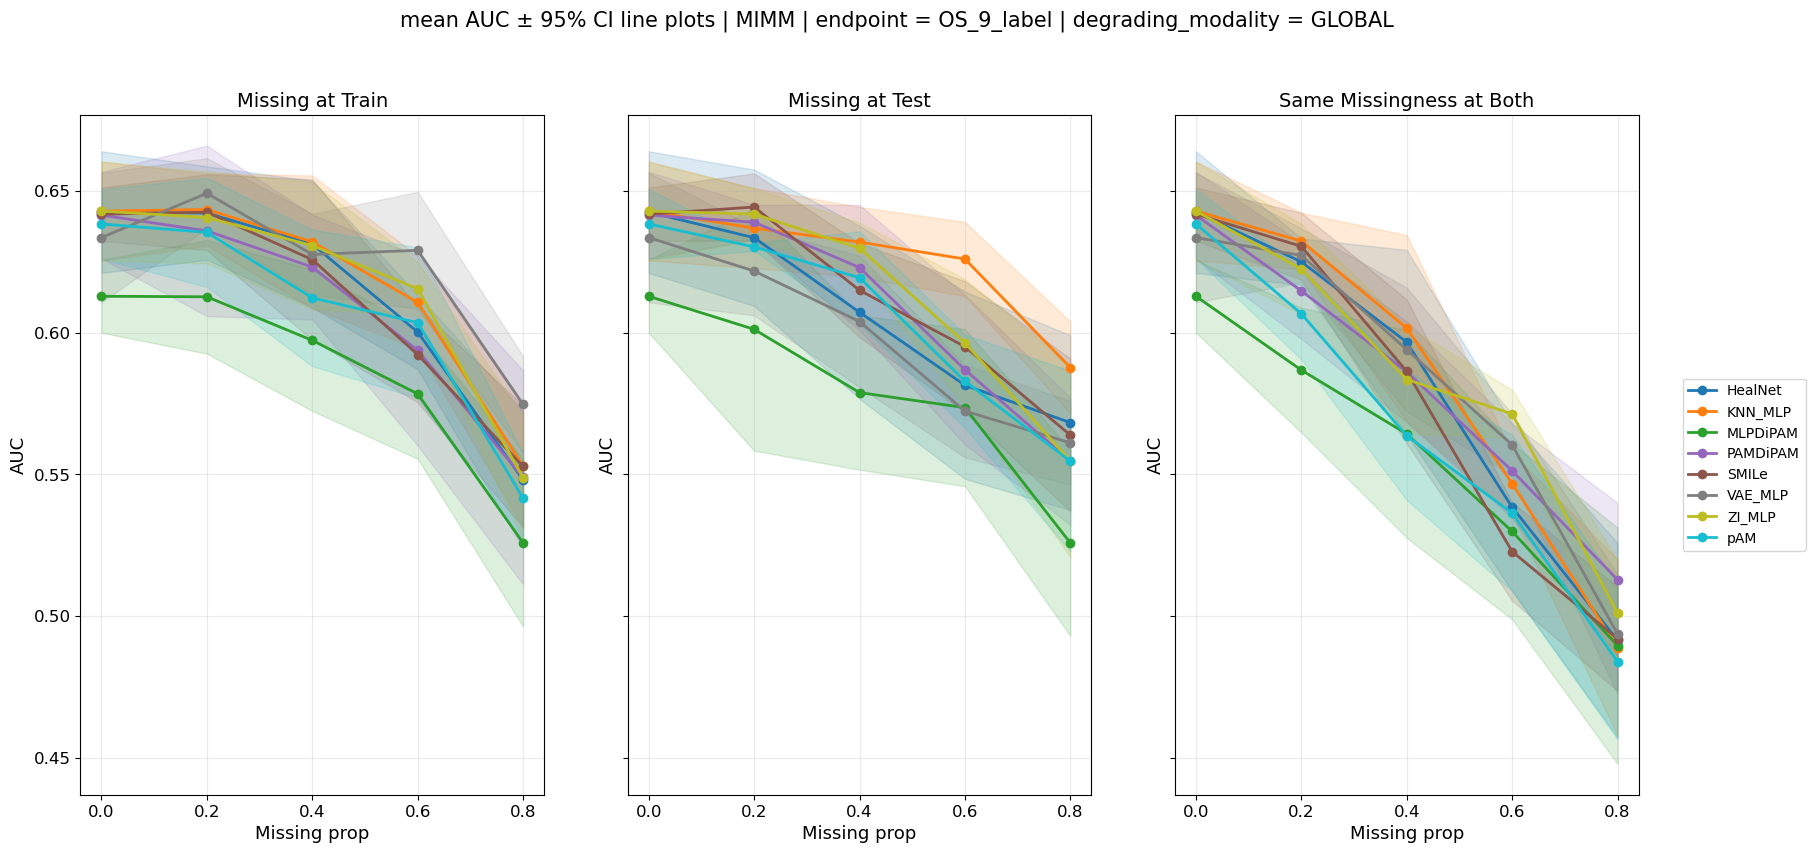

Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/figures/auc/both_heatmaps_mean_auc_MIMM_OS_9_label_global_8models.png


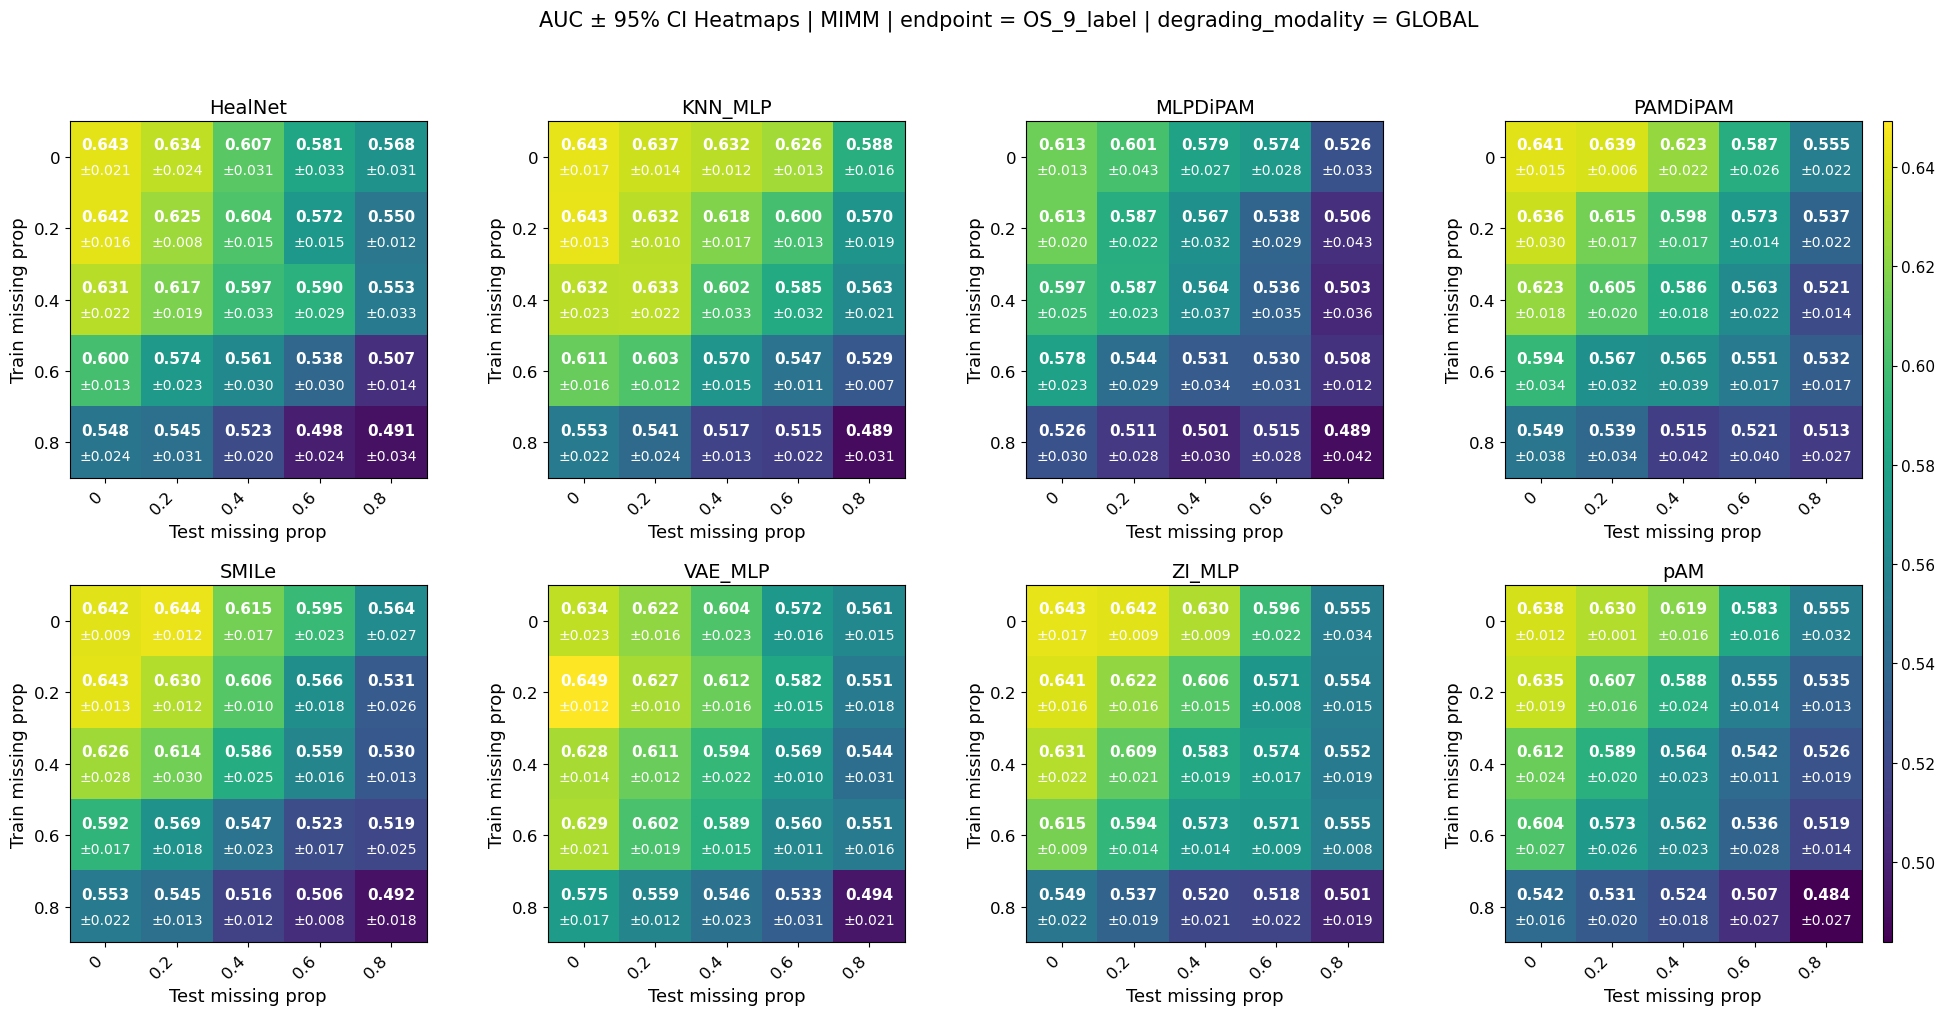

Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/figures/DC/degradation_coefficient_lines_MIMM_OS_9_label_global_8models.png


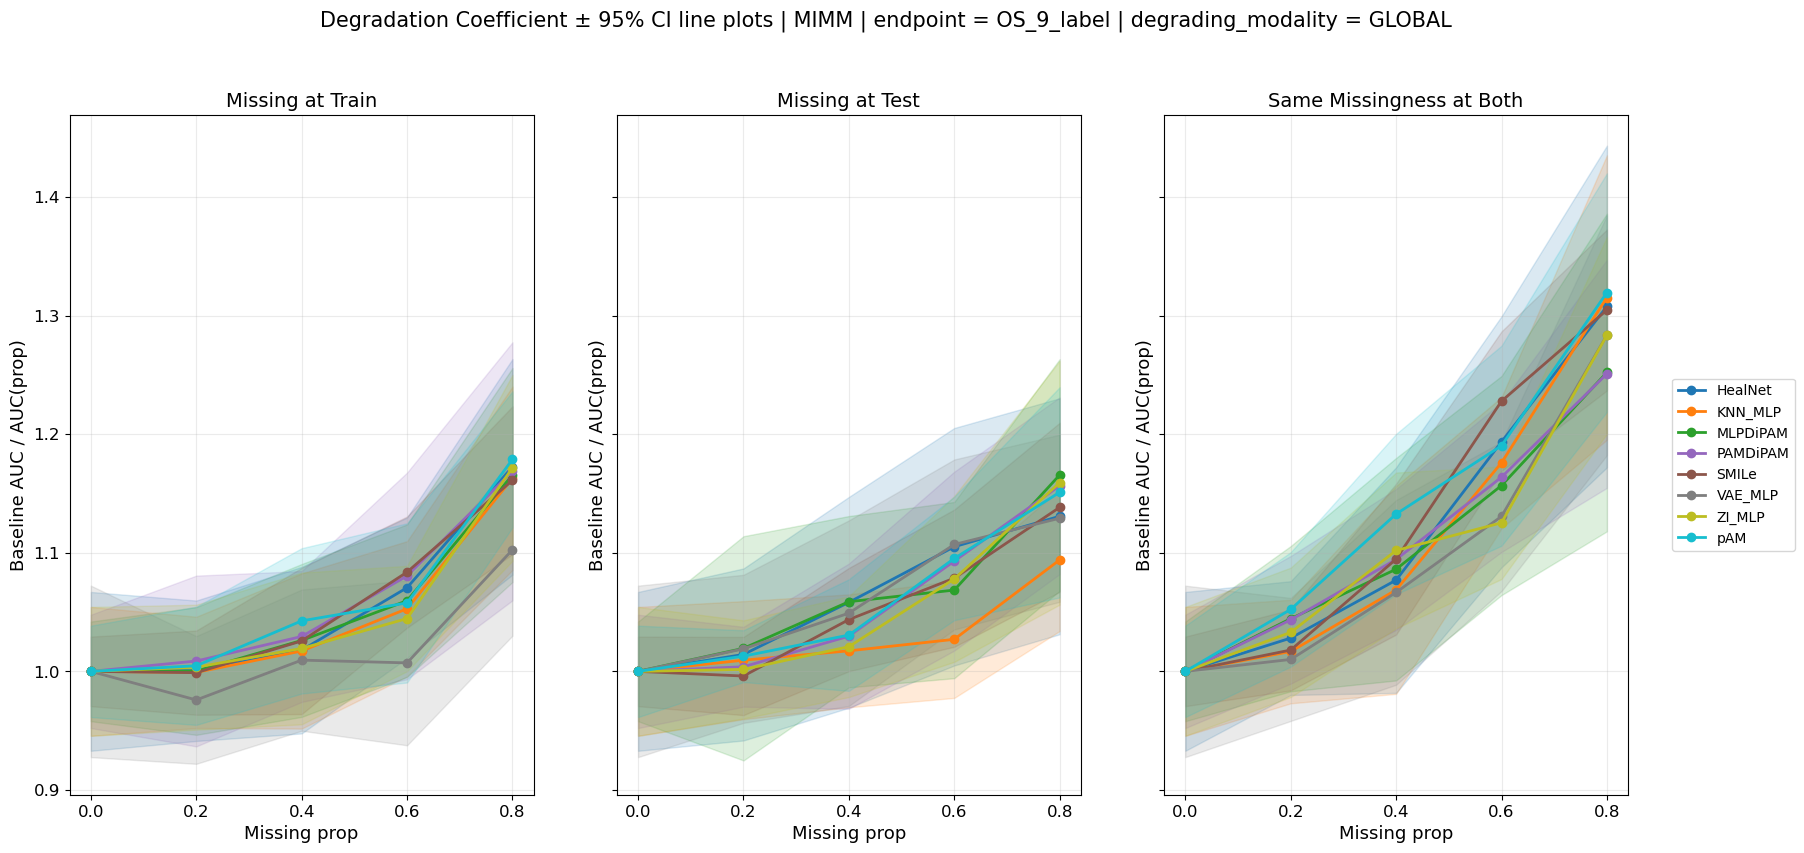

Saved figure to: /Users/marcalbesa/Desktop/TFM/git_exp/methods/analysis/figures/DC/both_heatmaps_degradation_coefficient_MIMM_OS_9_label_global_8models.png


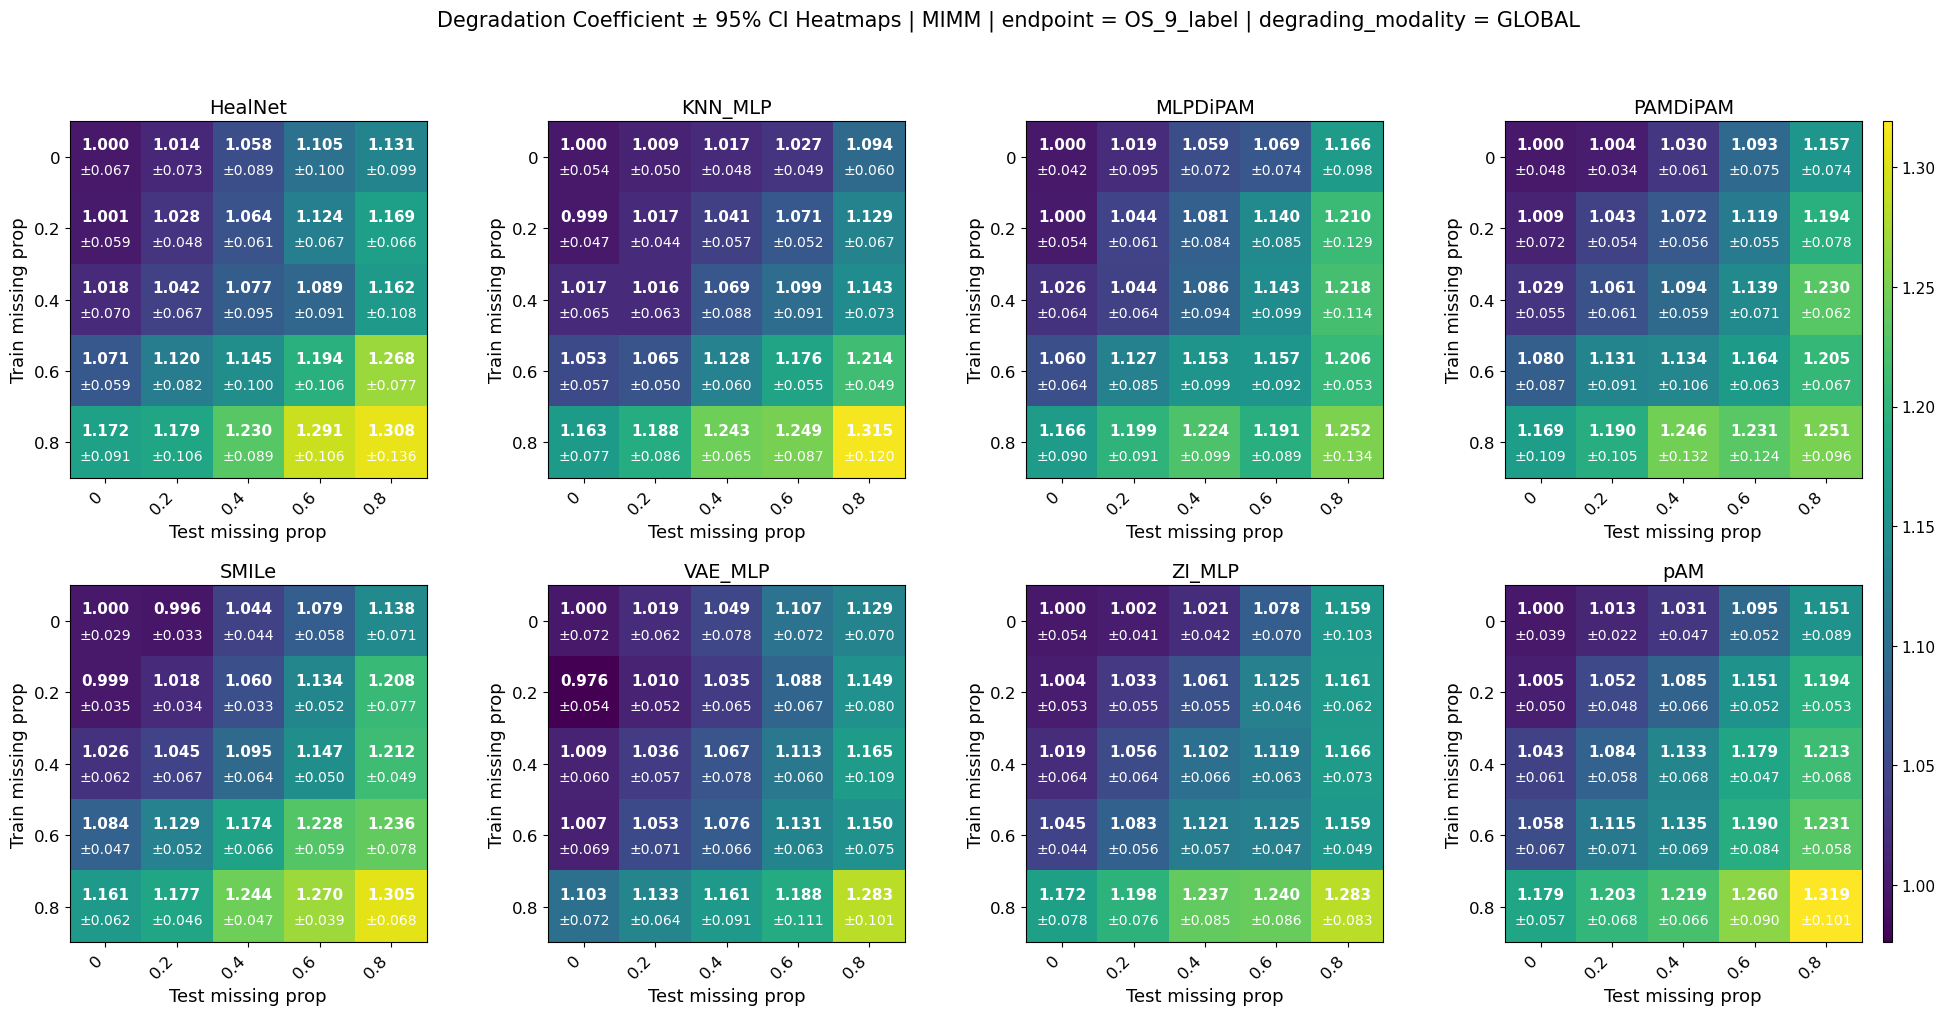

In [264]:
figures_dir = resolve_figures_dir()
auc_figures_dir = figures_dir / 'auc'
dc_figures_dir = figures_dir / 'DC'
root_tag = RESULTS_ROOT.parent.name
location_tag = TRAIN_MISSING_LOCATION.lower()
model_count_tag = f"{summary_df['model_name'].nunique()}models" if not summary_df.empty else '0models'

plot_line_pair(
    summary_df=summary_df,
    metric_col='mean_auc',
    title=f'mean AUC ± 95% CI line plots | {DATASET_NAME} | endpoint = {ENDPOINT_NAME} | degrading_modality = {TRAIN_MISSING_LOCATION}',
    ylabel='AUC',
    figures_dir=auc_figures_dir,
    file_name=f'degradation_mean_auc_lines_{root_tag}_{location_tag}_{model_count_tag}.png',
)

plot_horizontal_both_heatmaps(
    summary_df=summary_df,
    metric_col='mean_auc',
    title=f'AUC ± 95% CI Heatmaps | {DATASET_NAME} | endpoint = {ENDPOINT_NAME} | degrading_modality = {TRAIN_MISSING_LOCATION}',
    figures_dir=auc_figures_dir,
    file_name=f'both_heatmaps_mean_auc_{root_tag}_{location_tag}_{model_count_tag}.png',
)

plot_line_pair(
    summary_df=summary_df,
    metric_col='degradation_coefficient',
    title=f'Degradation Coefficient ± 95% CI line plots | {DATASET_NAME} | endpoint = {ENDPOINT_NAME} | degrading_modality = {TRAIN_MISSING_LOCATION}',
    ylabel='Baseline AUC / AUC(prop)',
    figures_dir=dc_figures_dir,
    file_name=f'degradation_coefficient_lines_{root_tag}_{location_tag}_{model_count_tag}.png',
)

plot_horizontal_both_heatmaps(
    summary_df=summary_df,
    metric_col='degradation_coefficient',
    title=f'Degradation Coefficient ± 95% CI Heatmaps | {DATASET_NAME} | endpoint = {ENDPOINT_NAME} | degrading_modality = {TRAIN_MISSING_LOCATION}',
    figures_dir=dc_figures_dir,
    file_name=f'both_heatmaps_degradation_coefficient_{root_tag}_{location_tag}_{model_count_tag}.png',
)
